In [1]:
import os

folder_path = "GpC26"

data = {}

'''
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        data[file] = load_spectrum(file_path)
        '''

'\nfor file in os.listdir(folder_path):\n    if file.endswith(".csv"):\n        file_path = os.path.join(folder_path, file)\n        data[file] = load_spectrum(file_path)\n        '

In [2]:
import pandas as pd

def load_spectrum(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()

    start_row = None
    for i, line in enumerate(lines):
        if "Channel" in line:
            start_row = i
            break

    df = pd.read_csv(file_path, skiprows=start_row)

    df.columns = df.columns.str.strip().str.replace(",", "")
    df = df.iloc[:, :3]
    df.columns = ["Channel", "Energy", "Counts"]

    df = df[["Channel", "Counts"]]

    df["Channel"] = pd.to_numeric(df["Channel"], errors="coerce")
    df["Counts"] = pd.to_numeric(df["Counts"], errors="coerce")

    df = df.dropna()

    return df

In [3]:
angle_data = {}

angle_data[-6] = load_spectrum("GpC26/-6degrees.csv")
angle_data[-5] = load_spectrum("GpC26/-5degrees.csv")
angle_data[-4] = load_spectrum("GpC26/-4degrees.csv")
angle_data[-3] = load_spectrum("GpC26/-3degrees.csv")
angle_data[-2] = load_spectrum("GpC26/-2degrees.csv")
angle_data[-1] = load_spectrum("GpC26/-1degrees.csv")
angle_data[0] = load_spectrum("GpC26/0degrees.csv")
angle_data[1] = load_spectrum("GpC26/1degree.csv")
angle_data[2] = load_spectrum("GpC26/2degrees.csv")
angle_data[3] = load_spectrum("GpC26/3degrees.csv")
angle_data[4] = load_spectrum("GpC26/4degrees.csv")
angle_data[5] = load_spectrum("GpC26/5degrees.csv")
angle_data[6] = load_spectrum("GpC26/6degrees.csv")

coince_on = load_spectrum("GpC26/20degrees20minutesgateon.csv")
coince_off = load_spectrum("GpC26/counter1_20deg_20min_nogate.csv")
detect2 = load_spectrum("GpC26/counter2_2h.csv")
callibration2 = load_spectrum("GpC26/counter1_5minsnocoincidence.csv")



In [4]:
poisson_68_table = {
    0: (0.0, 1.84),
    1: (0.17, 3.30),
    3: (1.37, 5.92),
    4: (2.09, 7.16),
    16: (12.04, 21.08),
    14: (10.03, 18.83),
}

Detector 1
511 peak:   319.07
1274 peak:  772.42
Resolution: 3.3%
E(511):     0.5263 ± 0.0173 MeV
Detector 2
511 peak:   312.48
1274 peak:  755.51
Resolution: 4.7%
E(511):     0.5269 ± 0.0247 MeV


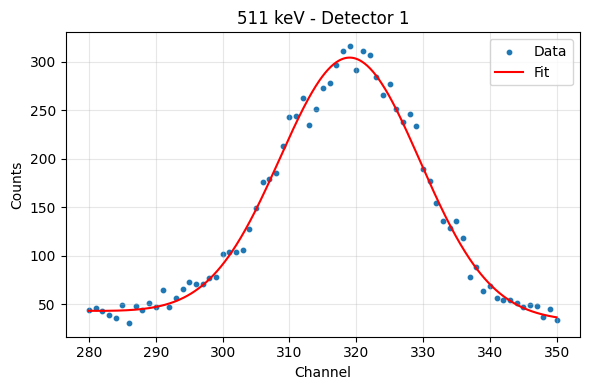

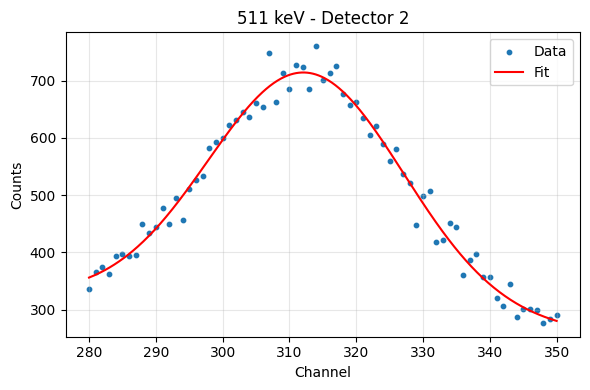

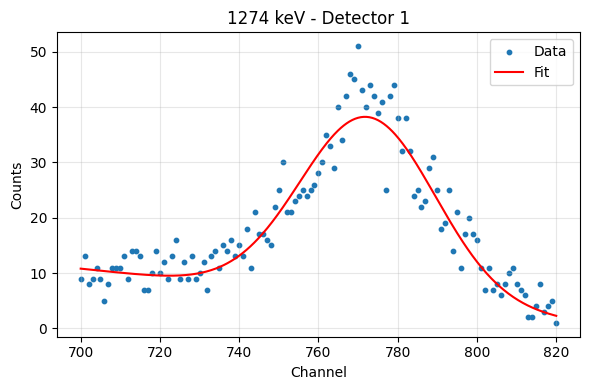

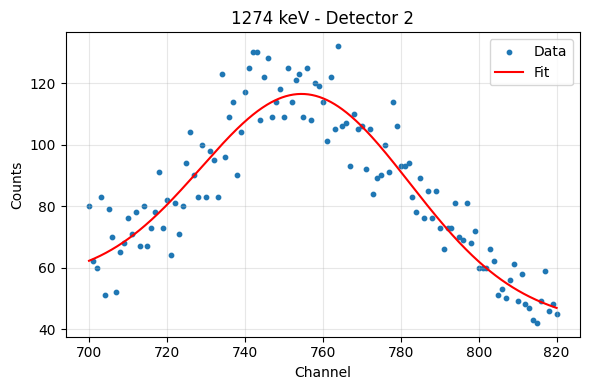

In [14]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


def model(x, A, mu, sigma, m, b):
    return A*np.exp(-(x-mu)**2/(2*sigma**2)) + (m*x + b)


def fit_peak(df, ch_min, ch_max):
    d = df[df["Channel"].between(ch_min, ch_max)]
    x, y = d["Channel"].values, d["Counts"].values

    yerr = np.sqrt(np.maximum(y, 1))

    p0 = [
        y.max() - y.min(),
        x[np.argmax(y)],
        (ch_max - ch_min)/6,
        0,
        np.mean(y)
    ]

    popt, pcov = curve_fit(
        model,
        x, y,
        p0=p0,
        sigma=yerr,
        absolute_sigma=True,
        maxfev=10000
    )

    mu = popt[1]
    mu_err = np.sqrt(pcov[1, 1])
    sigma = popt[2]

    return mu, mu_err, sigma, popt

def analyze_detector(df):
    
    mu_511, err_511, s511, p511 = fit_peak(df, 280, 350)
    mu_1274, err_1274, s1274, p1274 = fit_peak(df, 700, 820)

    
    FWHM_511 = 2.355 * s511
    R_511 = s511 / mu_511

   
    E_known = 1.274
    a = E_known / mu_1274
    a_err = a * (err_1274 / mu_1274)

   
    sigmaE_511 = a * s511

    
    E_511 = a * mu_511
    
    E_511_err_stat = E_511 * np.sqrt(
        (err_511 / mu_511)**2 +
        (a_err / a)**2
    )

    
    E_511_err = np.sqrt(E_511_err_stat**2 + sigmaE_511**2)

    return {
        "mu_511": mu_511,
        "mu_1274": mu_1274,
        "sigma_511": s511,
        "sigma_1274": s1274,
        "R_511": R_511,
        "a": a,
        "a_err": a_err,
        "E_511": E_511,
        "E_511_err": E_511_err,
        "fit_511": p511,
        "fit_1274": p1274
    }



def print_results(res, label):
    print(label)
    print(f"511 peak:   {res['mu_511']:.2f}")
    print(f"1274 peak:  {res['mu_1274']:.2f}")
    print(f"Resolution: {res['R_511']*100:.1f}%")
    print(f"E(511):     {res['E_511']:.4f} ± {res['E_511_err']:.4f} MeV")



def plot_peak(df, ch_min, ch_max, popt, title):
    d = df[df["Channel"].between(ch_min, ch_max)]
    x, y = d["Channel"].values, d["Counts"].values

    xfit = np.linspace(ch_min, ch_max, 500)
    yfit = model(xfit, *popt)

    plt.figure(figsize=(6,4))
    plt.scatter(x, y, s=10, label="Data")
    plt.plot(xfit, yfit, "r", label="Fit")

    plt.title(title)
    plt.xlabel("Channel")
    plt.ylabel("Counts")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()




df1 = coince_off
df2 = detect2  

res1 = analyze_detector(df1)
res2 = analyze_detector(df2)

print_results(res1, "Detector 1")
print_results(res2, "Detector 2")

plot_peak(df1, 280, 350, res1["fit_511"], "511 keV - Detector 1")
plot_peak(df2, 280, 350, res2["fit_511"], "511 keV - Detector 2")
plot_peak(df1, 700, 820, res1["fit_1274"], "1274 keV - Detector 1")
plot_peak(df2, 700, 820, res2["fit_1274"], "1274 keV - Detector 2")

,Angle (deg),Counts (N),Unc - (counts),Unc + (counts),Rate (counts/s),Unc - (counts/s),Unc + (counts/s)
0,-6,3,1.630,2.920,0.01000,0.00543,0.00973
1,-5,16,3.960,5.080,0.05333,0.01320,0.01693
2,-4,60,7.746,7.746,0.20000,0.02582,0.02582
3,-3,115,10.724,10.724,0.38333,0.03575,0.03575
4,-2,215,14.663,14.663,0.71667,0.04888,0.04888
5,-1,281,16.763,16.763,0.93667,0.05588,0.05588
6,0,285,16.882,16.882,0.95000,0.05627,0.05627
7,1,294,17.146,17.146,0.98000,0.05715,0.05715
8,2,250,15.811,15.811,0.83333,0.05270,0.05270
9,3,215,14.663,14.663,0.71667,0.04888,0.04888


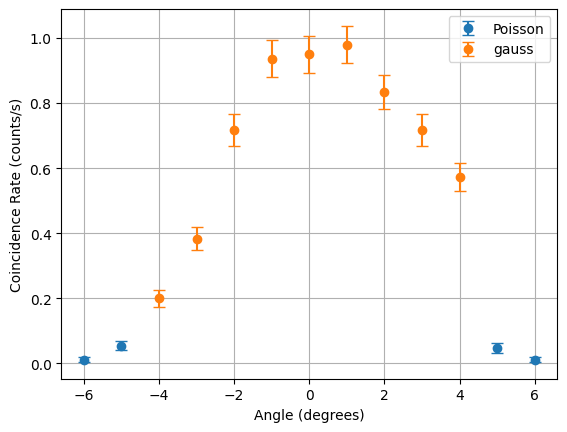

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_time = 300

low_angles, low_rates, low_err_low, low_err_high = [], [], [], []
high_angles, high_rates, high_err = [], [], []
rows = []

for angle, df in sorted(angle_data.items()):
    N = df[(df["Channel"].between(280, 350))]["Counts"].sum()
    R = N / run_time

    if N < 50 and N in poisson_68_table:
        low, high = poisson_68_table[N]
        e_low, e_high = (N - low)/run_time, (high - N)/run_time

        low_angles.append(angle)
        low_rates.append(R)
        low_err_low.append(e_low)
        low_err_high.append(e_high)

        unc_counts_low, unc_counts_high = N - low, high - N
        sigma_low, sigma_high = e_low, e_high

    else:
        e = np.sqrt(N)
        high_angles.append(angle)
        high_rates.append(R)
        high_err.append(e/run_time)

        unc_counts_low = unc_counts_high = e
        sigma_low = sigma_high = e / run_time

    rows.append({
        "Angle (deg)": angle,
        "Counts (N)": int(N),
        "Unc - (counts)": round(unc_counts_low, 3),
        "Unc + (counts)": round(unc_counts_high, 3),
        "Rate (counts/s)": round(R, 5),
        "Unc - (counts/s)": round(sigma_low, 5),
        "Unc + (counts/s)": round(sigma_high, 5)
    })

table = pd.DataFrame(rows).sort_values("Angle (deg)")
display(table)


plt.errorbar(low_angles, low_rates, yerr=[low_err_low, low_err_high],
             fmt='o', capsize=4, label="Poisson")
plt.errorbar(high_angles, high_rates, yerr=high_err,
             fmt='o', capsize=4, label="gauss")

plt.xlabel("Angle (degrees)")
plt.ylabel("Coincidence Rate (counts/s)")
plt.legend()
plt.grid(True)
plt.show()

mu = 0.493 ± 0.158 deg
Shape Chi^2 = 169.0612796997698
Shape Chi^2/dof = 14.088439974980817


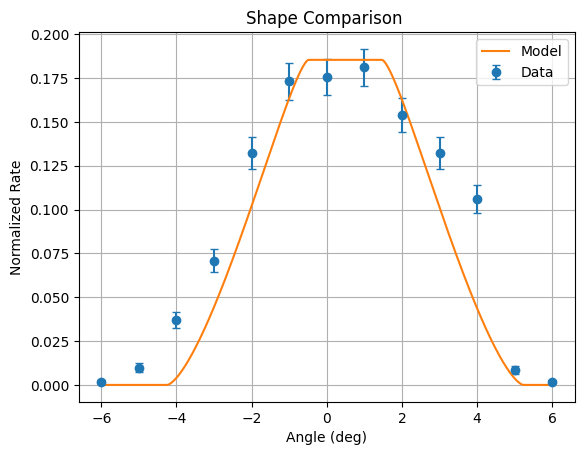

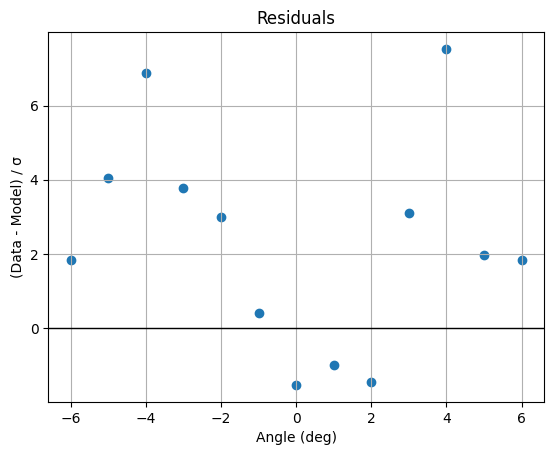

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

low_angles = np.array(low_angles)
low_rates = np.array(low_rates)
low_err_low = np.array(low_err_low)
low_err_high = np.array(low_err_high)

high_angles = np.array(high_angles)
high_rates = np.array(high_rates)
high_err = np.array(high_err)

angles = np.concatenate([low_angles, high_angles])
rates = np.concatenate([low_rates, high_rates])

yerr = np.concatenate([low_err_low, high_err])
yerr = np.vstack([yerr, yerr])


#center

from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


A0 = np.max(rates)
mu0 = angles[np.argmax(rates)]
sigma0 = 2.0 
popt, pcov = curve_fit(gaussian, angles, rates, p0=[A0, mu0, sigma0])

A_fit, mu_fit, sigma_fit = popt
mu_err = np.sqrt(pcov[1,1])

print(f"mu = {mu_fit:.3f} ± {mu_err:.3f} deg")




def circle_overlap(d, r1, r2):
    if d >= r1 + r2:
        return 0.0
    if d <= abs(r1 - r2):
        return np.pi * min(r1, r2)**2

    a = np.arccos((r1**2 + d**2 - r2**2) / (2 * r1 * d))
    b = np.arccos((r2**2 + d**2 - r1**2) / (2 * r2 * d))

    return (
        r1**2 * a +
        r2**2 * b -
        0.5 * np.sqrt(
            (-d + r1 + r2) *
            ( d + r1 - r2) *
            ( d - r1 + r2) *
            ( d + r1 + r2)
        )
    )

L1, r1 = 44.45, 4.445 / 2
L2, r2 = 23.1775, 1.524 / 2

Leff = (L1 * L2) / (L1 + L2)

alpha1 = np.arctan(r1 / L1)
alpha2 = np.arctan(r2 / L2)

r1_eff = Leff * np.tan(alpha1)
r2_eff = Leff * np.tan(alpha2)


def model(theta_deg, shift=0.0):
    theta = np.radians(theta_deg - shift)   # APPLY SHIFT HERE
    d = Leff * np.tan(theta)

    return np.array([
        circle_overlap(abs(di), r1_eff, r2_eff)
        for di in d
    ])


model_raw = model(angles, shift=mu_fit)

data_area = np.trapezoid(rates, angles)
model_area = np.trapezoid(model_raw, angles)

data_shape = rates / data_area
model_shape = model_raw / model_area

chi2_shape = np.sum((data_shape - model_shape)**2)



yerr_norm = yerr[0] / data_area

chi2_shape = np.sum(((data_shape - model_shape) / yerr_norm)**2)
dof = len(angles) - 1

print("Shape Chi^2 =", chi2_shape)
print("Shape Chi^2/dof =", chi2_shape / dof)



x = np.linspace(np.min(angles), np.max(angles), 400)
model_smooth = model(x, shift=mu_fit)
model_smooth /= np.trapezoid(model_smooth, x)

plt.errorbar(
    angles,
    data_shape,
    yerr=yerr / data_area,
    fmt='o',
    capsize=3,
    label="Data"
)

plt.plot(x, model_smooth, label="Model")

plt.title("Shape Comparison ")
plt.xlabel("Angle (deg)")
plt.ylabel("Normalized Rate")
plt.legend()
plt.grid()

plt.show()

model_at_points = model(angles, shift=mu_fit)
model_norm = model_at_points / np.trapezoid(model_at_points, angles)

residuals = (data_shape - model_norm) / (yerr[0] / data_area)

plt.figure()

plt.axhline(0, color='black', linewidth=1)
plt.scatter(angles, residuals)

plt.title("Residuals")
plt.xlabel("Angle (deg)")
plt.ylabel("(Data - Model) / σ")
plt.grid()

plt.show()

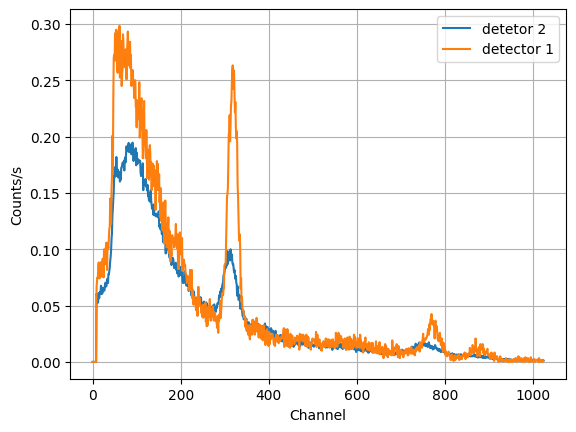

In [ ]:
plt.plot(detect2['Counts']/7600, label ="detetor 2")
plt.plot(coince_off['Counts']/1200,label ="detector 1")


plt.xlabel("Channel")
plt.ylabel("Counts/s")
plt.grid()
plt.legend()
plt.show()

,Angle (deg),Counts (N),Unc - (counts),Unc + (counts),Rate (counts/s),Unc - (counts/s),Unc + (counts/s)
0,-6,0,0.00,1.84,0.00000,0.00000,0.00613
1,-5,0,0.00,1.84,0.00000,0.00000,0.00613
2,-4,0,0.00,1.84,0.00000,0.00000,0.00613
3,-3,0,0.00,1.84,0.00000,0.00000,0.00613
4,-2,0,0.00,1.84,0.00000,0.00000,0.00613
5,-1,0,0.00,1.84,0.00000,0.00000,0.00613
6,0,0,0.00,1.84,0.00000,0.00000,0.00613
7,1,0,0.00,1.84,0.00000,0.00000,0.00613
8,2,1,0.83,2.30,0.00333,0.00277,0.00767
9,3,0,0.00,1.84,0.00000,0.00000,0.00613


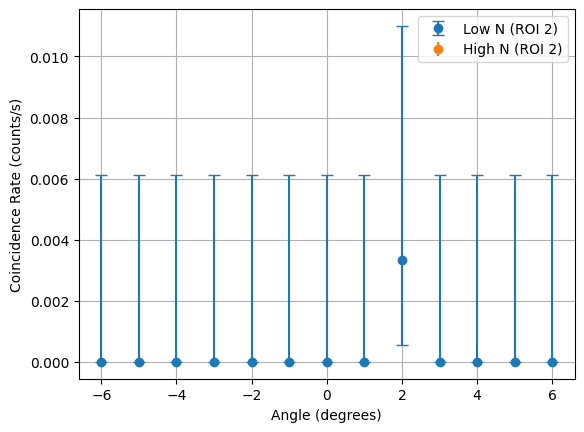

In [ ]:
low_angles2, low_rates2, low_err_low2, low_err_high2 = [], [], [], []
high_angles2, high_rates2, high_err2 = [], [], []
rows2 = []

for angle, df in sorted(angle_data.items()):
    N2 = df[(df["Channel"].between(730, 820))]["Counts"].sum()
    R2 = N2 / run_time
    
    if N2 < 50 and N2 in poisson_68_table:
        low, high = poisson_68_table[N2]
        e_low, e_high = (N2 - low)/run_time, (high - N2)/run_time
        low_angles2.append(angle)
        low_rates2.append(R2)
        low_err_low2.append(e_low)
        low_err_high2.append(e_high)
        unc_counts_low, unc_counts_high = N2 - low, high - N2
        sigma_low, sigma_high = e_low, e_high
    else:
        e = np.sqrt(N2)
        high_angles2.append(angle)
        high_rates2.append(R2)
        high_err2.append(e/run_time)
        unc_counts_low = unc_counts_high = e
        sigma_low = sigma_high = e / run_time

    rows2.append({
        "Angle (deg)": angle,
        "Counts (N)": int(N2),
        "Unc - (counts)": round(unc_counts_low, 3),
        "Unc + (counts)": round(unc_counts_high, 3),
        "Rate (counts/s)": round(R2, 5),
        "Unc - (counts/s)": round(sigma_low, 5),
        "Unc + (counts/s)": round(sigma_high, 5)
    })

table2 = pd.DataFrame(rows2).sort_values("Angle (deg)")
display(table2)

plt.errorbar(low_angles2, low_rates2, yerr=[low_err_low2, low_err_high2], fmt='o', capsize=4, label="Low N (ROI 2)")
plt.errorbar(high_angles2, high_rates2, yerr=high_err2, fmt='o', capsize=4, label="High N (ROI 2)")
plt.xlabel("Angle (degrees)")
plt.ylabel("Coincidence Rate (counts/s)")
plt.legend()
plt.grid(True)
plt.show()


In [42]:

import numpy as np

def get_roi_counts(df, low_channel=280, high_channel=350):
    roi = df[df["Channel"].between(low_channel, high_channel)]
    return roi["Counts"].sum()
def get_total_counts(df, low_channel=0, high_channel=1024):
    roi = df[df["Channel"].between(low_channel, high_channel)]
    return roi["Counts"].sum()
def poisson_bounds(N, poisson_68_table):
    if N in poisson_68_table:
        low, high = poisson_68_table[N]
        return low, high
    else:
        sigma = np.sqrt(N)
        return N - sigma, N + sigma


t1 = 1200
t2 = 7600


N_on = get_total_counts(coince_on)
N_off = get_total_counts(coince_off)/t1
t_expect = 0.00000025
N_2 = get_roi_counts(detect2)/t2

N_on_r = get_roi_counts(coince_on)
N_off_r = get_roi_counts(coince_off)
N_2_r = get_roi_counts(detect2)
tau = (N_on_r * t2) / (N_off_r * N_2)
rel_err = np.sqrt(1/N_on_r + 1/N_off_r + 1/N_2_r)
tau_gauss_err = tau * rel_err


print(N_off*t_expect/N_2)



on_low, on_high = poisson_bounds(N_on, poisson_68_table)
off_low, off_high = poisson_bounds(N_off, poisson_68_table)
n2_low, n2_high = poisson_bounds(N_2, poisson_68_table)


tau_plus = (on_high * t2) / (off_low * n2_low)
tau_minus = (on_low * t2) / (off_high * n2_high)

tau_err_plus = tau_plus - tau
tau_err_minus = tau - tau_minus

print(f"tau (Gaussian) = {tau:.3e} ± {tau_gauss_err:.1e} s")
print(f"tau (asymmetric) = {tau:.3e} +{tau_err_plus:.1e} -{tau_err_minus:.1e} s")

2.904142340839588e-06
tau (Gaussian) = 1.645e-01 ± 1.6e-01 s
tau (asymmetric) = 1.645e-01 +4.5e+02 --3.7e+01 s


In [52]:
import numpy as np

def get_roi_counts(df, low_channel=280, high_channel=350):
    roi = df[df["Channel"].between(low_channel, high_channel)]
    return roi["Counts"].sum()

def get_total_counts(df, low_channel=0, high_channel=1024):
    roi = df[df["Channel"].between(low_channel, high_channel)]
    return roi["Counts"].sum()

tau = 2.5e-7

t_on = 1200
t_off = 1200
t_2 = 7200

N1 = get_total_counts(coince_off)
N2 = get_roi_counts(detect2)
N_on = get_total_counts(coince_on)

n1 = N1 / t_off
n2 = N2 / t_2
R_meas = N_on / t_on

R_pred = n1 * n2 * tau

sigma_n1 = np.sqrt(N1) / t_off
sigma_n2 = np.sqrt(N2) / t_2

rel_err = np.sqrt((sigma_n1 / n1) ** 2 + (sigma_n2 / n2) ** 2)
sigma_R_pred = R_pred * rel_err

N_pred_gate = N2 * (n1 * tau)
R_pred_gate = N_pred_gate / t_2
sigma_R_pred_gate = R_pred_gate * rel_err

sigma_R_meas = np.sqrt(N_on) / t_on


print(f"true gate on rate = {R_meas:.3e} ± {sigma_R_meas:.1e}")

print("calulated rate:")
print(f"R_pred = {R_pred:.3e} ± {sigma_R_pred:.1e} Hz\n")

print("Gate interpretation (detector 2 defines the gate):")
print(f"R_pred = {R_pred_gate:.3e} ± {sigma_R_pred_gate:.1e} Hz\n")

diff = abs(R_meas - R_pred)

print("Difference:")
print(f"|R_meas - R_pred| = {diff:.3e}\n")

T = 1200

N_gates = n2 * T
N_acc = N_gates * (n1 * tau)

rel_err_N = np.sqrt((sigma_n1 / n1) ** 2 + (sigma_n2 / n2) ** 2)
sigma_N_acc = N_acc * rel_err_N


print(f"Number of gates (detector 2): {N_gates:.2f}")
print(f"Accidental coincidences in 20 min: {N_acc:.2f} ± {sigma_N_acc:.4f}")

true gate on rate = 3.333e-03 ± 1.7e-03
calulated rate:
R_pred = 6.867e-05 ± 4.5e-07 Hz

Gate interpretation (detector 2 defines the gate):
R_pred = 6.867e-05 ± 4.5e-07 Hz

Difference:
|R_meas - R_pred| = 3.265e-03

Number of gates (detector 2): 5995.00
Accidental coincidences in 20 min: 0.08 ± 0.0005
